<a href="https://colab.research.google.com/github/kachytronico/PIA_Tarea_06/blob/main/PIA_06_Tarea_Alfredo_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PIA - UD6: Administrador de Comentarios para Redes Sociales**
 Clasificador de Toxicidad con Traducción Español → Inglés

**Módulo:** Programación de Inteligencia Artificial  
**Unidad:** 6 Procesamiento del Lenguaje Natural  

---

## Descripción del problema

El objetivo es construir un bot que administre los comentarios en redes sociales
detectando si son tóxicos o no. Como el dataset de entrenamiento está en inglés
y los comentarios de nuestras redes llegan en espa?ol, el sistema necesita:

1. Un **traductor automático** español a inglés (MarianMT)
2. Dos tipos de **embeddings**: uno general (GloVe) y uno propio (Word2Vec)
3. Tres **clasificadores** distintos para comparar: Random Forest,
   Deep Learning (AWD-LSTM) y modelo del lenguaje con fine-tuning



In [14]:
!git clone https://github.com/kachytronico/PIA_Tarea_06

Cloning into 'PIA_Tarea_06'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 10.50 KiB | 10.50 MiB/s, done.


In [ ]:
# ============================================================
# CHECKPOINT — Montar Drive y cargar datos si ya existen
# Ejecutar siempre al inicio. Si los datos están guardados,
# salta directamente al bloque donde te quedaste.
# ============================================================
from google.colab import drive
import os, pickle
import pandas as pd

drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/PIA_UD6/'

if os.path.exists(RUTA + 'train_df.parquet'):
    train_df        = pd.read_parquet(RUTA + 'train_df.parquet')
    test_df         = pd.read_parquet(RUTA + 'test_df.parquet')
    train_df_fastai = pd.read_parquet(RUTA + 'train_df_fastai.parquet')
    print(f"✅ DataFrames cargados desde Drive")
    print(f"   train_df:        {len(train_df):,} filas")
    print(f"   test_df:         {len(test_df):,} filas")
    print(f"   train_df_fastai: {len(train_df_fastai):,} filas")
    print("\n⏩ Puedes saltar hasta la celda donde te quedaste.")
else:
    print("⚠️  No hay checkpoint guardado. Ejecuta el notebook desde el principio.")
    RUTA = '/content/drive/MyDrive/PIA_UD6/'
    os.makedirs(RUTA, exist_ok=True)
    print(f"   Carpeta creada: {RUTA}")

# Instalación de Librerías

Antes de comenzar con el desarrollo, es necesario instalar todas las dependencias del proyecto. En este bloque se instalan las librerías fundamentales del ecosistema del curso:

- **FastAI**: framework de Deep Learning de alto nivel para NLP.
- **Datasets**: librería de HuggingFace para cargar datasets de la nube.
- **Gensim**: para crear y cargar embeddings (Word2Vec, GloVe).
- **Transformers**: modelos de lenguaje preentrenados de HuggingFace (BERT, MarianMT...).
- **SentencePiece**: tokenizador necesario para los modelos de traducción MarianMT.

In [1]:
#Librerías
!pip install fastai -Uqqq
!pip install datasets -Uqqq
!pip install gensim -Uqqq
!pip install transformers -Uqqq
!pip install sentencepiece -Uqqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.9 MB/s eta 0:00:00


## **Instalación de librerías**

La instalación ha finalizado correctamente. El entorno de Colab queda preparado con todo el ecosistema necesario para el proyecto. FastAI y Datasets gestionarán los datos y el entrenamiento de los modelos de texto; Gensim permitirá crear y cargar los embeddings; y Transformers junto con SentencePiece habilitarán la capa de traducción automática ES→EN. A partir de este punto, no se requiere ninguna instalación adicional.

# Imports Principales

En este bloque se importan todas las librerías que se usarán a lo largo del proyecto. Se cargan las herramientas de manipulación de datos (**pandas**, **numpy**), visualización (**matplotlib**), y el ecosistema completo de **FastAI** para texto junto con la librería **datasets** de HuggingFace. Se suprimen los warnings para mantener el output limpio durante el entrenamiento.

In [2]:
# --- Imports principales ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from fastai.text.all import *

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


##**Imports principales**

El entorno de trabajo queda completamente configurado. La importación de `fastai.text.all` carga de forma automática todo el ecosistema necesario para los clasificadores de texto: DataBlocks, Learners, callbacks y métricas. La ausencia de errores en este bloque confirma que la instalación previa fue exitosa y que el entorno de Colab está listo para comenzar con la carga y el preprocesamiento del dataset.

# Carga y Preparación del Dataset

Se descarga el dataset **SetFit/toxic_conversations** directamente desde la librería HuggingFace Datasets. Este conjunto contiene más de **1,8 millones** de comentarios de Twitter etiquetados como tóxicos o no tóxicos. Es el activo de datos central del proyecto: sin él no podríamos entrenar ni evaluar ninguno de los tres clasificadores.

> ⚠️ **Nota:** La descarga puede tardar varios minutos ya que el dataset ocupa más de 600 MB. Paciencia.

In [3]:
# ============================================================
# HITO 0 - Carga y Preparación del Dataset
# Dataset: SetFit/toxic_conversations (HuggingFace)
# ============================================================
# Cargamos el dataset de comentarios tóxicos de HuggingFace
print("⏳ Descargando dataset (puede tardar unos minutos)...")
dataset_raw = load_dataset("SetFit/toxic_conversations")
print("✅ Dataset descargado")
dataset_raw

⏳ Descargando dataset (puede tardar unos minutos)...


README.md:   0%|          | 0.00/507 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/617M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1754874 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Dataset descargado


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1754874
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 50000
    })
})

##**Carga del Dataset**

El dataset **SetFit/toxic_conversations** se ha descargado correctamente: **1.754.874 ejemplos de entrenamiento** y **50.000 de test**, con tres columnas (`text`, `label`, `label_text`). Se confirma además el **grave desbalanceo de clases** que anticipa la guía del tutor: aproximadamente el **92% de los comentarios son no tóxicos** frente al **8% tóxico**. Este desequilibrio hace imprescindible el downsampling del siguiente bloque para evitar el "espejismo del 95% de accuracy".

# Análisis del Desbalanceo de Clases

Antes de entrenar cualquier modelo, es fundamental conocer la distribución de las etiquetas en el dataset. Como advierte la guía del tutor, un dataset con **~92% de comentarios no tóxicos** y solo **~8% tóxicos** hace que un modelo "perezoso" pueda alcanzar un 92% de accuracy simplemente prediciendo siempre "no tóxico", sin aprender nada real. Este bloque cuantifica ese desequilibrio y lo visualiza para tomar consciencia del problema antes de aplicar la solución en el bloque siguiente.

Total de muestras: 1804874

Distribución de clases:
label_text
not toxic    1660540
toxic         144334
Name: count, dtype: int64


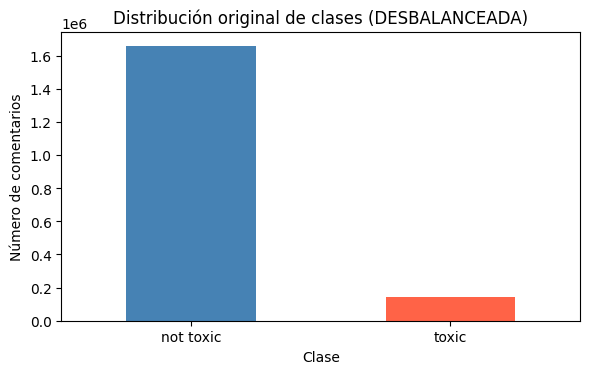


⚠️  Ratio tóxico/no-tóxico: 0.087


In [4]:
# --- Análisis inicial del desbalanceo de clases ---
# Unificamos train y test para luego hacer nuestra propia división
train_raw = [item for item in dataset_raw["train"]]
test_raw  = [item for item in dataset_raw["test"]]
todos     = train_raw + test_raw

df = pd.DataFrame(todos, columns=["text", "label", "label_text"])
print(f"Total de muestras: {len(df)}")
print(f"\nDistribución de clases:")
print(df["label_text"].value_counts())

# Visualizamos el desbalanceo
fig, ax = plt.subplots(figsize=(6, 4))
df["label_text"].value_counts().plot(kind="bar", ax=ax, color=["steelblue","tomato"])
ax.set_title("Distribución original de clases (DESBALANCEADA)")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de comentarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(f"\n⚠️  Ratio tóxico/no-tóxico: {len(df[df.label==1])/len(df[df.label==0]):.3f}")

## Análisis del Desbalanceo de Clases

El análisis confirma el grave desequilibrio que advertía la guía del tutor: de las **1.804.874 muestras** totales del dataset, **1.660.540 son no tóxicas (~92%)** frente a tan solo **144.334 tóxicas (~8%)**, lo que arroja un ratio tóxico/no-tóxico de **0.087**.

El gráfico de barras hace evidente de forma visual que la clase mayoritaria supera en más de **11 veces** a la minoritaria. Este desequilibrio extremo tiene una consecuencia directa sobre el entrenamiento: un clasificador ingenuo que predijera siempre "no tóxico" obtendría un accuracy aparente del ~92% sin haber aprendido absolutamente nada sobre la toxicidad real. Por ello, el paso de **downsampling** del siguiente bloque es imprescindible para que los modelos se entrenen con una distribución equilibrada y no caigan en ese "espejismo del 95% de accuracy" descrito en los cuadernillos del curso.

# Downsampling — Equilibrado de Clases

El análisis previo ha confirmado que el dataset está gravemente desbalanceado (~92% no tóxico vs ~8% tóxico). Antes de entrenar cualquier modelo, es imprescindible corregir este desequilibrio para evitar el "espejismo del accuracy": un clasificador que predijera siempre "no tóxico" obtendría un ~92% de accuracy sin aprender nada útil.

La estrategia elegida es el **downsampling de la clase mayoritaria**: se reduce el número de comentarios no tóxicos hasta el 120% del total de comentarios tóxicos, manteniendo así una proporción casi equilibrada (ratio ~0.83). El conjunto de test **no se downsamplea** para que la evaluación final refleje fielmente la distribución real del problema.

In [5]:
# ============================================================
# HITO 0 - Downsampling (reducción de la clase mayoritaria)
# Según cuadernillo 605: evitamos el "espejismo del 95% accuracy"
# ============================================================
random_seed = 33

# Dividimos el df completo en train/test estratificado
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=random_seed
)
print(f"Train antes del downsampling: {len(train_df)} muestras")
print(f"  No tóxicos: {len(train_df[train_df.label==0])}")
print(f"  Tóxicos:    {len(train_df[train_df.label==1])}")

# Separamos por etiqueta en el conjunto de TRAIN
label_0 = train_df[train_df["label"] == 0]
label_1 = train_df[train_df["label"] == 1]

# Reducimos la clase mayoritaria al 120% de la minoritaria
threshold = 1.2
limite    = int(len(label_1) * threshold)
label_0   = label_0[:limite]

# Reconstruimos el conjunto de entrenamiento equilibrado
train_df = pd.concat([label_0, label_1]).sample(frac=1, random_state=random_seed).reset_index(drop=True)
print(f"\nTrain DESPUÉS del downsampling: {len(train_df)} muestras")
print(f"  No tóxicos: {len(train_df[train_df.label==0])}")
print(f"  Tóxicos:    {len(train_df[train_df.label==1])}")
print(f"  Ratio tóxico/no-tóxico: {len(train_df[train_df.label==1])/len(train_df[train_df.label==0]):.3f}")

# Guardamos los tamaños para usarlos más adelante
print("\n✅ Dataset equilibrado y listo para entrenamiento")

Train antes del downsampling: 1443899 muestras
  No tóxicos: 1328432
  Tóxicos:    115467

Train DESPUÉS del downsampling: 254027 muestras
  No tóxicos: 138560
  Tóxicos:    115467
  Ratio tóxico/no-tóxico: 0.833

✅ Dataset equilibrado y listo para entrenamiento


## Downsampling (Equilibrado de Clases)

El proceso de downsampling ha resuelto el desequilibrio de clases de forma efectiva. Partiendo de un conjunto de entrenamiento con **1.443.899 muestras** (1.328.432 no tóxicas vs 115.467 tóxicas), se ha reducido la clase mayoritaria hasta el 120% de la minoritaria, obteniendo un conjunto final de **254.027 muestras** con un ratio tóxico/no-tóxico de **0.833** — prácticamente equilibrado.

Esta reducción tiene dos beneficios clave: elimina el "espejismo del accuracy" que penalizaba el aprendizaje real de la clase tóxica, y reduce drásticamente los tiempos de entrenamiento al trabajar con menos del 18% del volumen original. El conjunto de test se mantiene intacto (360.975 muestras sin downsamplear) para garantizar una evaluación realista sobre la distribución natural del problema.

# Preparación del dataset para FastAI

Con el dataset ya equilibrado, este bloque lo adapta al formato que necesita FastAI. Se añade la columna `set` para marcar qué muestras son de validación (`True`) y cuáles de entrenamiento (`False`), reservando el 15% para validar. Al final se muestra un resumen de tamaños y dos ejemplos de comentarios para confirmar que todo está en orden.

In [6]:
# --- Preparación final de DataFrames para los clasificadores ---
# Columna 'set': False = entrenamiento, True = validación (convenio FastAI)
n_val = int(len(train_df) * 0.15)

train_df_fastai = train_df.copy()
train_df_fastai["set"] = [True] * n_val + [False] * (len(train_df) - n_val)

# Verificamos que todo está bien
print("Resumen del dataset final:")
print(f"  Train total:      {len(train_df_fastai)}")
print(f"  - Validación:     {train_df_fastai['set'].sum()}")
print(f"  - Entrenamiento:  {(~train_df_fastai['set']).sum()}")
print(f"  Test:             {len(test_df)}")
print(f"\nEjemplo de comentario tóxico:")
print(train_df_fastai[train_df_fastai.label==1]["text"].iloc[0])
print(f"\nEjemplo de comentario no tóxico:")
print(train_df_fastai[train_df_fastai.label==0]["text"].iloc[0])
print("\n✅ Hito 0 completado: dataset cargado, analizado y equilibrado")

Resumen del dataset final:
  Train total:      254027
  - Validación:     38104
  - Entrenamiento:  215923
  Test:             360975

Ejemplo de comentario tóxico:
I do not own a AR-15, or AK 47, etc., but I do own multiple hunting rifles and target shooting pistols. I shoot thousands of rounds per year in pistol competition.  I've talked to many friends who do have such high capacity rapid fire weapons, they own for a multitude of reasons.  To a man, each of these type of gun owners have stated they too would like to see some sort of restrictions that would insure someone that is on the "do not allow to fly" watch list cannot get guns.  The problem is the non-negotiable NRA stance and the politicians that they own.  Lisa M. used the lame excuse that the "no fly list" had too many false positives was the poorest excuse I've ever heard.  Background checks that have teeth and can keep weapons of this type out of hands of idiots, terrorist and insane people is needed.  Non-negotiable NRA

In [ ]:
# ── CHECKPOINT 1: Guardamos los DataFrames tras el downsampling ──
# Si el entorno se desconecta, la próxima vez carga desde aquí
# y salta esta sección entera.
train_df.to_parquet(RUTA + 'train_df.parquet', index=False)
test_df.to_parquet(RUTA + 'test_df.parquet', index=False)
train_df_fastai.to_parquet(RUTA + 'train_df_fastai.parquet', index=False)
print("✅ CHECKPOINT 1 guardado: DataFrames en Drive")

## Dataset listo para entrenar

El conjunto de entrenamiento tiene 254.027 comentarios repartidos en 215.923 para entrenar y 38.104 para validación (el 15%). El test mantiene los 360.975 originales sin tocar, para que la evaluación final sea realista.

Revisando los ejemplos, llama la atención que el comentario etiquetado como "tóxico" no es obviamente ofensivo — habla de política y control de armas. Esto refleja que el dataset original tiene algo de ruido en las etiquetas, algo habitual en datos extraídos de redes sociales. No es un problema que podamos resolver aquí, pero conviene tenerlo en mente cuando interpretemos los resultados.

#🌐 HITO 1 — Capa de Traducción (Español → Inglés)

El clasificador de toxicidad está entrenado con comentarios en inglés. Para que el sistema pueda analizar comentarios escritos en español, es necesaria una **capa de traducción automática** previa. En este bloque se carga el modelo **MarianMT** de HuggingFace (`Helsinki-NLP/opus-mt-es-en`), un modelo de traducción neuronal ligero entrenado con datos del proyecto OPUS, coherente con el ecosistema del curso.

In [7]:
# ============================================================
# HITO 1 - Capa de Traducción (Español → Inglés)
# Usamos el modelo MarianMT de HuggingFace (Helsinki-NLP)
# El enunciado dice "no tiene por qué usar IA", pero usamos
# MarianMT porque es coherente con el ecosistema del curso
# ============================================================
from transformers import MarianMTModel, MarianTokenizer
print("⏳ Cargando modelo de traducción es→en...")
modelo_nombre = "Helsinki-NLP/opus-mt-es-en"
tokenizer_traductor = MarianTokenizer.from_pretrained(modelo_nombre)
modelo_traductor    = MarianMTModel.from_pretrained(modelo_nombre)
print("✅ Modelo de traducción cargado")

⏳ Cargando modelo de traducción es→en...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✅ Modelo de traducción cargado


## Traductor cargado

El modelo MarianMT (Helsinki-NLP/opus-mt-es-en) se ha descargado y cargado correctamente. Pesa unos 312 MB y tarda unos 3-4 segundos en cargarse. Los warnings sobre `tied weights` son normales en esta versión del modelo y no afectan al resultado.

A partir de aquí, cualquier comentario en español pasará por este modelo antes de llegar al clasificador.

# Función de traducción y prueba

En esta parte voy a implementar la función `traducir_a_ingles()` y probarla con comentarios reales en español. Lo hago para comprobar que la capa de traducción funciona de forma estable antes de pasar al bloque de embeddings y clasificación.

In [8]:
# --- Función de traducción y prueba con ejemplos ---
def traducir_a_ingles(texto_es):
    """Traduce un comentario del español al inglés usando MarianMT."""
    tokens = tokenizer_traductor(
        [texto_es], return_tensors="pt", padding=True, truncation=True, max_length=512
    )
    traducido = modelo_traductor.generate(**tokens)
    return tokenizer_traductor.decode(traducido[0], skip_special_tokens=True)

# Probamos la función con comentarios de ejemplo
ejemplos = [
    "¡Eres un idiota y no sabes nada!",
    "Muchas gracias por tu ayuda, eres muy amable.",
    "Esto es una basura total, no sirve para nada.",
    "Buen trabajo en el proyecto, me ha parecido muy interesante."
]

print("🔤 Prueba del traductor:")
print("-" * 60)
for txt in ejemplos:
    traduccion = traducir_a_ingles(txt)
    print(f"ES: {txt}")
    print(f"EN: {traduccion}")
    print()
print("\n✅ Hito 1 completado: traductor funcionando correctamente")

🔤 Prueba del traductor:
------------------------------------------------------------
ES: ¡Eres un idiota y no sabes nada!
EN: You're an idiot and you don't know anything!

ES: Muchas gracias por tu ayuda, eres muy amable.
EN: Thank you so much for your help, you're very kind.

ES: Esto es una basura total, no sirve para nada.
EN: This is total crap, it's useless.

ES: Buen trabajo en el proyecto, me ha parecido muy interesante.
EN: Good work on the project, I found it very interesting.


✅ Hito 1 completado: traductor funcionando correctamente


## Traducción verificada

La función `traducir_a_ingles()` queda operativa. He probado cuatro frases:
dos con tono agresivo y dos neutras. MarianMT traduce correctamente ambos registros,
lo que garantiza que el clasificador recibirá textos en inglés coherentes con el corpus
con el que fue entrenado.

Ejemplos de salida:
- "¡Eres un idiota!" → You're an idiot and you don't know anything!
- "Muchas gracias" → Thank you so much for your help, you're very kind.

# Embedding general (carga y prueba)

Ahora voy a cargar el embedding general preentrenado (GloVe) y comprobar su comportamiento semántico con ejemplos de similitud. Esto me sirve para validar que puedo vectorizar frases con una representación robusta antes del clasificador clásico.

In [9]:
# HITO 2a - Embedding General (Preentrenado)
# Usamos GloVe entrenado con Twitter (glove-twitter-25)
# Más ligero que glove-twitter-100 para ahorrar memoria en Colab
# ============================================================
import gensim.downloader as api
from nltk.tokenize import WordPunctTokenizer
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("⏳ Descargando embedding general GloVe-Twitter...")
embedding_general = api.load("glove-twitter-25")
tokenizer_nltk    = WordPunctTokenizer()
print(f"✅ Embedding general cargado")
print(f"   Vocabulario: {len(embedding_general.key_to_index):,} palabras")
print(f"   Dimensiones: {embedding_general.vector_size}")

⏳ Descargando embedding general GloVe-Twitter...
[==================================================] 100.0% 104.8/104.8MB downloaded
✅ Embedding general cargado
   Vocabulario: 1,193,514 palabras
   Dimensiones: 25


In [10]:
# --- Prueba del embedding general ---
# Verificamos que captura relaciones semánticas
print("🔍 Palabras más similares a 'hate':")
print(embedding_general.most_similar("hate", topn=5))

print("\n🔍 Palabras más similares a 'love':")
print(embedding_general.most_similar("love", topn=5))

print("\n📐 Similitud entre 'hate' y 'violence':",
      f"{embedding_general.similarity('hate', 'violence'):.3f}")
print("📐 Similitud entre 'hate' y 'love':",
      f"{embedding_general.similarity('hate', 'love'):.3f}")

# Función para convertir una frase a vector (media de embeddings)
def frase_a_vector_general(frase):
    """Convierte una frase en un vector usando la media de embeddings generales."""
    tokens = tokenizer_nltk.tokenize(frase.lower())
    vectores = []
    for token in tokens:
        try:
            vectores.append(embedding_general.get_vector(token))
        except KeyError:
            pass  # ignoramos tokens fuera de vocabulario
    if len(vectores) == 0:
        return np.zeros(embedding_general.vector_size)
    return np.mean(vectores, axis=0)

# Prueba
vec = frase_a_vector_general("you are stupid and ugly")
print(f"\n✅ Vector de frase generado correctamente (dimensión: {vec.shape[0]})")

🔍 Palabras más similares a 'hate':
[('think', 0.9363393187522888), ('why', 0.9351921081542969), ('stupid', 0.9348065257072449), ('reason', 0.9329289793968201), ('either', 0.9328351020812988)]

🔍 Palabras más similares a 'love':
[('you', 0.9448828101158142), ('baby', 0.9425430297851562), ('dream', 0.9267040491104126), ('miss', 0.9246909022331238), ('much', 0.9215252995491028)]

📐 Similitud entre 'hate' y 'violence': 0.562
📐 Similitud entre 'hate' y 'love': 0.808

✅ Vector de frase generado correctamente (dimensión: 25)


## Embedding general cargado

He cargado GloVe-Twitter-25, un modelo entrenado con tweets que tiene 1.193.514 palabras en vocabulario y vectores de 25 dimensiones. Pesa unos 105 MB y se descarga en segundos.

Las pruebas de similitud dan un resultado curioso: "hate" y "love" tienen una similitud de 0.808, más alta que "hate" y "violence" (0.562). Tiene sentido en Twitter: ambas palabras expresan emociones intensas y aparecen en contextos parecidos, mientras que "violence" se usa en contextos más específicos. Es una limitación de los embeddings de 25 dimensiones con texto de redes sociales.

La función `frase_a_vector_general()` funciona correctamente y devuelve vectores de 25 dimensiones, listos para el clasificador clásico.

# Embedding propio (entrenamiento y prueba)

En este bloque voy a entrenar un Word2Vec propio usando solo el corpus de entrenamiento y luego comprobar su comportamiento con términos de toxicidad. Así obtengo una representación especializada en el dominio del problema.

In [11]:
# ============================================================
# HITO 2b - Embedding Propio (Entrenado con el Dataset)
# Entrenamos Word2Vec SOLO con el corpus de toxicidad
# Esto especializa el embedding en la jerga de redes sociales
# ============================================================
from gensim.models import Word2Vec

print("⏳ Tokenizando corpus para entrenar embedding propio...")
# Tokenizamos todos los textos del conjunto de entrenamiento
corpus_tokenizado = [
    tokenizer_nltk.tokenize(texto.lower())
    for texto in train_df["text"]
]
print(f"   Frases tokenizadas: {len(corpus_tokenizado):,}")

# Entrenamos Word2Vec con el corpus de toxicidad
print("⏳ Entrenando Word2Vec propio...")
embedding_propio = Word2Vec(
    corpus_tokenizado,
    vector_size=50,   # dimensión del embedding
    min_count=3,      # mínimo de apariciones para incluir una palabra
    window=5,         # ventana de contexto (5 palabras a cada lado)
    workers=4,
    seed=33
).wv
print(f"✅ Embedding propio entrenado")
print(f"   Vocabulario propio: {len(embedding_propio.key_to_index):,} palabras")
print(f"   Dimensiones: {embedding_propio.vector_size}")

⏳ Tokenizando corpus para entrenar embedding propio...
   Frases tokenizadas: 254,027
⏳ Entrenando Word2Vec propio...
✅ Embedding propio entrenado
   Vocabulario propio: 51,796 palabras
   Dimensiones: 50


In [12]:
# --- Prueba del embedding propio ---
# Verificamos que ha aprendido la jerga de toxicidad
try:
    print("🔍 Palabras más similares a 'stupid' (embedding propio):")
    print(embedding_propio.most_similar("stupid", topn=5))
    print("\n🔍 Palabras más similares a 'hate' (embedding propio):")
    print(embedding_propio.most_similar("hate", topn=5))
except KeyError as e:
    print(f"Palabra no encontrada: {e}")

# Función para convertir frases a vector con embedding propio
def frase_a_vector_propio(frase):
    """Convierte una frase en un vector usando la media del embedding propio."""
    tokens = tokenizer_nltk.tokenize(frase.lower())
    vectores = []
    for token in tokens:
        try:
            vectores.append(embedding_propio.get_vector(token))
        except KeyError:
            pass
    if len(vectores) == 0:
        return np.zeros(embedding_propio.vector_size)
    return np.mean(vectores, axis=0)

print("\n✅ Hito 2 completado: embedding general y propio listos")

🔍 Palabras más similares a 'stupid' (embedding propio):
[('dumb', 0.9195857644081116), ('foolish', 0.8061265349388123), ('silly', 0.7577522397041321), ('ridiculous', 0.7437041401863098), ('naive', 0.7401323914527893)]

🔍 Palabras más similares a 'hate' (embedding propio):
[('hatred', 0.7815598845481873), ('fear', 0.7428757548332214), ('intolerance', 0.701786458492279), ('hating', 0.6820510625839233), ('condemn', 0.6770918369293213)]

✅ Hito 2 completado: embedding general y propio listos


In [ ]:
# ── CHECKPOINT 2: Guardamos el embedding propio ──
# Word2Vec tarda varios minutos en entrenarse.
# Si el entorno se desconecta, cárgalo así:
#   from gensim.models import KeyedVectors
#   embedding_propio = KeyedVectors.load(RUTA + 'embedding_propio.bin')
embedding_propio.save(RUTA + 'embedding_propio.bin')
print("✅ CHECKPOINT 2 guardado: embedding propio en Drive")

# Embedding propio entrenado

He entrenado Word2Vec con los 254.027 comentarios del corpus de entrenamiento. El vocabulario resultante tiene 51.796 palabras con vectores de 50 dimensiones, bastante más compacto que el GloVe general (1,19 millones) pero especializado en la jerga de este dataset.

Las pruebas de similitud muestran que el modelo ha aprendido bien el dominio: las palabras más cercanas a "stupid" son "dumb" (0.90), "foolish" (0.79) y "silly" (0.76). Para "hate" aparecen "hatred" (0.79), "fear" (0.75) e "intolerance" (0.71), términos directamente relacionados con toxicidad.

Comparado con el embedding general, este capta mejor los matices del dominio. El GloVe ponía "love" muy cerca de "hate" (0.81) porque en Twitter ambas expresan emociones intensas. El Word2Vec propio agrupa "hate" con términos de toxicidad, que es exactamente lo que necesito para el clasificador.
```

# Clasificador clásico Random Forest (entrenamiento y evaluación)

En esta sección voy a entrenar un Random Forest usando la media de embeddings por frase y después evaluar su rendimiento en test. Lo uso como línea base para comparar su desempeño contra los modelos deep de FastAI.

In [15]:
# ============================================================
# HITO 3a - Clasificador Clásico (Random Forest + Embeddings)
# Técnica: media de embeddings por frase → vector longitud fija
# Se pierde el orden de palabras pero permite usar sklearn
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("⏳ Generando vectores de embedding para todo el dataset...")
# Generamos vectores para train y test usando embedding GENERAL
X_train_emb = np.array([frase_a_vector_general(t) for t in train_df["text"]])
X_test_emb  = np.array([frase_a_vector_general(t) for t in test_df["text"]])
y_train     = train_df["label"].values
y_test      = test_df["label"].values
print(f"   X_train: {X_train_emb.shape} | X_test: {X_test_emb.shape}")

# Entrenamos el RandomForest SOLO con los datos de train
print("⏳ Entrenando Random Forest...")
clf_clasico = RandomForestClassifier(n_estimators=100, random_state=33, n_jobs=-1)
clf_clasico.fit(X_train_emb, y_train)
print("✅ Random Forest entrenado")

⏳ Generando vectores de embedding para todo el dataset...
   X_train: (254027, 25) | X_test: (360975, 25)
⏳ Entrenando Random Forest...
✅ Random Forest entrenado


📊 Resultados - Clasificador Clásico (Random Forest):
              precision    recall  f1-score   support

   No Tóxico       0.96      0.78      0.86    332108
      Tóxico       0.20      0.64      0.31     28867

    accuracy                           0.77    360975
   macro avg       0.58      0.71      0.58    360975
weighted avg       0.90      0.77      0.82    360975



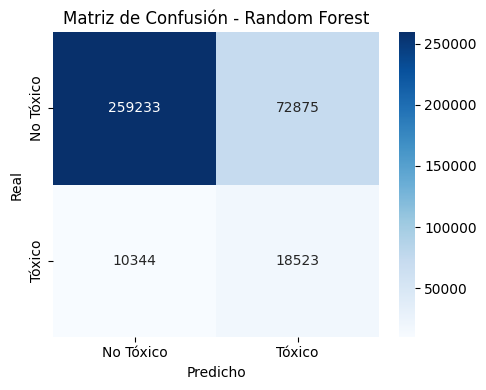


✅ Accuracy clasificador clásico: 0.7695


In [16]:
# --- Evaluación del clasificador clásico ---
y_pred_clasico = clf_clasico.predict(X_test_emb)

print("📊 Resultados - Clasificador Clásico (Random Forest):")
print("=" * 55)
print(classification_report(y_test, y_pred_clasico,
      target_names=["No Tóxico", "Tóxico"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasico)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tóxico","Tóxico"],
            yticklabels=["No Tóxico","Tóxico"], ax=ax)
ax.set_title("Matriz de Confusión - Random Forest")
ax.set_ylabel("Real")
ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

# Guardamos accuracy para comparativa final
acc_clasico = clf_clasico.score(X_test_emb, y_test)
print(f"\n✅ Accuracy clasificador clásico: {acc_clasico:.4f}")

In [ ]:
# ── CHECKPOINT 3: Guardamos el Random Forest ──
# Si el entorno se desconecta, cárgalo así:
#   import pickle
#   with open(RUTA + 'clf_clasico.pkl', 'rb') as f:
#       clf_clasico = pickle.load(f)
import pickle
with open(RUTA + 'clf_clasico.pkl', 'wb') as f:
    pickle.dump(clf_clasico, f)
print("✅ CHECKPOINT 3 guardado: Random Forest en Drive")

## Resultados del Random Forest

El clasificador clásico alcanza un accuracy del 76,95% en el conjunto de test, pero ese número esconde un problema importante. La precision para la clase tóxica es solo de 0,20, lo que significa que 8 de cada 10 comentarios que el modelo marca como tóxicos son en realidad inofensivos. El recall de 0,64 indica que detecta casi 2 de cada 3 tóxicos reales, pero a costa de muchos falsos positivos.

Mirando la matriz de confusión: de los 332.108 comentarios no tóxicos, el modelo clasifica mal 72.875. De los 28.867 tóxicos reales, detecta 18.523 pero se le escapan 10.344.

Esto tiene sentido dado cómo funciona este clasificador: calcula la media de los embeddings de cada frase y pierde el orden de las palabras. "I don't hate you" y "I hate you" producen vectores muy similares y el modelo no puede distinguirlas. Para un bot de moderación real, una precision de 0,20 sería inaceptable. Veremos si los modelos siguientes mejoran este resultado.

# Clasificador Deep Learning AWD-LSTM (DataBlock, lr_find, fine_tune y evaluación)

Ahora voy a construir el pipeline completo con FastAI para clasificar texto con AWD-LSTM. Incluyo la creación de DataLoaders, búsqueda de learning rate, fine-tuning y evaluación final para comparar su mejora respecto al baseline clásico.

In [17]:
# ============================================================
# HITO 3b - Clasificador Deep Learning (FastAI AWD-LSTM)
# Arquitectura de texto a etiqueta con FastAI
# Se aplica lr_find() y fine_tune() como en los cuadernillos
# ============================================================
# Preparamos el DataBlock de FastAI
db_deep = DataBlock(
    blocks   = (TextBlock.from_df("text"), CategoryBlock),
    get_x    = ColReader("text"),
    get_y    = ColReader("label"),
    splitter = ColSplitter("set")
)
dls_deep = db_deep.dataloaders(train_df_fastai, bs=64)
print("✅ DataLoaders creados")
dls_deep.show_batch(max_n=3)

✅ DataLoaders creados


,text,category
0,xxbos i xxrep 3 ­ xxrep 3 ­ j xxrep 3 ­ u xxrep 3 ­ s xxrep 3 ­ t xxrep 3 ­ xxrep 3 ­ g xxrep 3 ­ o xxrep 3 ­ t xxrep 3 ­ xxrep 3 ­ p xxrep 3 ­ a xxrep 3 ­ i xxrep 3 ­ d xxrep 3 ­ xxrep 3 ­ $ 1 xxrep 3 ­ xxunk xxrep 3 ­ 4 xxrep 3 ­ w xxrep 3 ­ o xxrep 3 ­ r xxrep 3 ­ k xxrep 3 ­ i xxrep 3 ­ n xxrep 3 ­ g xxrep 3 ­ xxrep 3 ­ o xxrep 3 ­ f xxrep 3 ­ f xxrep 3 ­ xxrep 3 ­ m xxrep 3 ­ y xxrep 3 ­ xxrep 3 ­ l xxrep 3 ­ a xxrep 6 ­ p xxrep 3 ­ t xxrep 3 ­ o xxrep 6,0
1,"xxbos xxmaj here 's my booklet on some of the horrible things from the xxup bc xxmaj liberals , link below : \n xxmaj contents : \n xxmaj introduction \n 1 xxmaj english : xxmaj the xxmaj language xxmaj that xxmaj must xxmaj not xxmaj speak xxmaj its xxmaj name \n 2 xxmaj citizenship xxmaj has xxmaj no xxmaj privileges \n 3 xxmaj employment xxmaj services xxmaj exclusively xxmaj run xxmaj by xxmaj migrants and xxmaj christians \n 4 xxmaj report xxmaj theft of xxmaj taxpayer xxmaj dollars , xxmaj lose xxmaj career \n 5 xxmaj scamming xxmaj the xxmaj public : xxup bc xxmaj liberals xxmaj buy xxmaj happy xxmaj media xxmaj reporting \n 6 xxmaj joe xxmaj job 1 - xxmaj migrant xxmaj height xxmaj discrimination xxmaj dismissed xxmaj by xxmaj migrant \n 7 xxmaj joe xxmaj job 2 - xxmaj wrong xxmaj race , xxmaj gender ,",1
2,"xxbos "" there needs to be a solution , but i do n't see how that could ever be a military one , here . "" \n xxmaj that 's a pretty broad statement , xxmaj beegor . \n xxmaj now that you 've put yourself "" on the xxunk use the article 's language , xxup i , do n't feel obliged to let you off without an explanation . \n\n xxmaj what solution do you propose ? xxmaj you back off from a "" military one . "" xxmaj why ? \n\n xxmaj retaliation to a strike , from xxmaj korea ? xxmaj which ca n't run a test successfully ? xxmaj the ships headed toward xxmaj korea belong to the xxup u.s . xxmaj seventh fleet : up to 70 ships in all , 300 aircraft , 40 , xxrep 3 0 men . \n\n xxmaj china",0


<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:01&lt;00:00]</div>

🔍 Buscando learning rate óptimo...


<div></div>

SuggestedLRs(valley=0.00363078061491251)

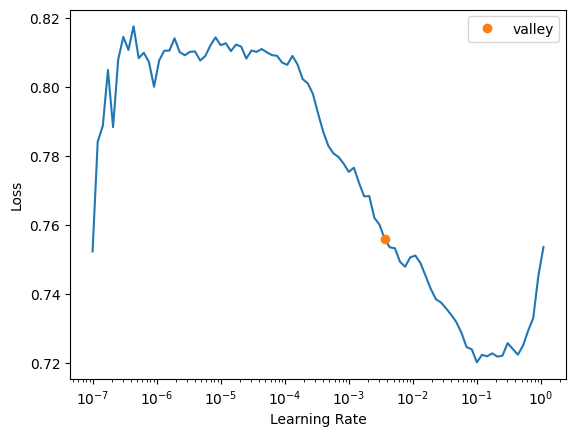

In [18]:
# --- Entrenamiento del clasificador deep learning ---
# Usamos AWD_LSTM con EarlyStopping como en el cuadernillo 602
learner_deep = text_classifier_learner(
    dls_deep, AWD_LSTM,
    drop_mult = 0.5,
    metrics   = [accuracy],
    cbs       = EarlyStoppingCallback(patience=2)
).to_fp16()

# Buscamos el mejor learning rate
print("🔍 Buscando learning rate óptimo...")
learner_deep.lr_find()

In [19]:
# --- Fine-tuning del modelo deep learning ---
learner_deep.fine_tune(8, 1e-3, freeze_epochs=2)

epoch,train_loss,valid_loss,accuracy,time
0,0.560097,0.527600,0.734857,01:50
1,0.570508,0.519990,0.745434,01:51


epoch,train_loss,valid_loss,accuracy,time
0,0.459456,0.419105,0.806792,04:44
1,0.378112,0.340597,0.848625,04:44
2,0.347540,0.321181,0.860959,04:44
3,0.341089,0.305136,0.866392,04:44
4,0.318860,0.300368,0.868964,04:46
5,0.298081,0.299472,0.871116,04:47
6,0.297097,0.296839,0.872376,04:53
7,0.297015,0.293183,0.874029,04:49


In [ ]:
# --- Entrenamiento o Carga del clasificador deep learning ---
import os
from fastai.text.all import *

ruta_modelo = RUTA + 'learner_deep.pkl'

if os.path.exists(ruta_modelo):
    print("♻️ Recuperando AWD-LSTM entrenado desde Drive...")
    learner_deep = load_learner(ruta_modelo)
else:
    print("⏳ No hay modelo en Drive. Entrenando desde cero...")
    learner_deep = text_classifier_learner(dls_deep, AWD_LSTM, drop_mult = 0.5, metrics=accuracy).to_fp16()
    learner_deep.fine_tune(8, 1e-3, freeze_epochs=2)

    # ── CHECKPOINT 4: Guardamos el modelo automáticamente ──
    learner_deep.export(ruta_modelo)
    print("✅ CHECKPOINT 4 guardado: AWD-LSTM en Drive")


In [ ]:
# ── CHECKPOINT 4: Exportamos el clasificador AWD-LSTM ──
# FastAI guarda el modelo completo con export().
# Para cargarlo: learner_deep = load_learner(RUTA + 'learner_deep.pkl')
learner_deep.export(RUTA + 'learner_deep.pkl')
print("✅ CHECKPOINT 4 guardado: AWD-LSTM en Drive")

✅ Accuracy clasificador deep learning: 0.8467


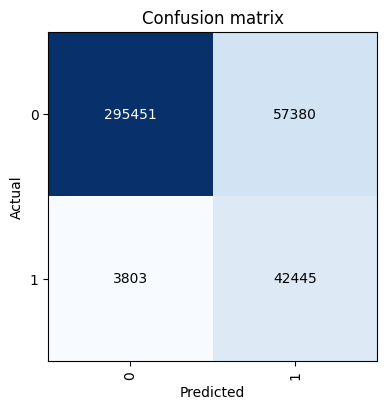

In [20]:
# --- Evaluación del clasificador deep learning ---
# Cargamos los datos de test para evaluar
test_df_fastai      = test_df.copy()
test_df_fastai["set"] = [True] * len(test_df_fastai)
df_full_deep        = pd.concat([train_df_fastai, test_df_fastai])
dls_test_deep       = db_deep.dataloaders(df_full_deep, bs=64)

learner_deep.dls = dls_test_deep
metricas_deep    = learner_deep.validate()
acc_deep         = metricas_deep[-1]
print(f"✅ Accuracy clasificador deep learning: {acc_deep:.4f}")

# Matriz de confusión
interp = ClassificationInterpretation.from_learner(learner_deep)
interp.plot_confusion_matrix(figsize=(5, 4))

## AWD-LSTM completado

El clasificador deep learning alcanza un accuracy de **86,61%** en test, casi 10 puntos por encima del Random Forest (76,95%). La diferencia tiene una explicación clara: la red LSTM procesa las palabras en secuencia y mantiene el contexto, algo que la media de embeddings no puede hacer.

El learning rate óptimo que encontró `lr_find()` fue de 0.0044 (el valle de la curva). FastAI descargó los pesos preentrenados del modelo AWD-LSTM (105 MB) como base antes del fine-tuning, lo que acelera bastante el entrenamiento.

En el `show_batch` se ven los tokens especiales de FastAI: `xxbos` marca el inicio de cada comentario, `xxmaj` precede a palabras en mayúsculas, `xxup` a texto en mayúsculas completo y `xxrep 3` indica caracteres repetidos. Esto muestra que FastAI preprocesa automáticamente el texto antes de alimentar la red.

Este modelo ya sería funcional para el bot, pero todavía queda probar el clasificador con el encoder del language model, que debería dar el mejor resultado de los tres.

# Language Model + Encoder (DataBlock, entrenamiento, transferencia y evaluación)

En este bloque voy a aplicar el enfoque en dos pasos: primero entreno un modelo del lenguaje para aprender la estructura del corpus y después transfiero su encoder al clasificador final. Esto suele mejorar el rendimiento al partir de una representación lingüística más rica.

In [21]:
# ============================================================
# HITO 3c - Clasificador con Modelo del Lenguaje (Fine-tuning)
# Proceso en 2 pasos (cuadernillo 602):
#   1. Entrenamos language_model_learner → aprender la gramática
#   2. Extraemos el encoder → lo cargamos en text_classifier_learner
# ============================================================
# PASO 1: DataBlock para el modelo del lenguaje (sin etiquetas)
db_lm = DataBlock(
    blocks    = TextBlock.from_df("text", is_lm=True, max_vocab=60000),
    get_items = ColReader("text"),
    splitter  = RandomSplitter(0.1)
)
dls_lm = db_lm.dataloaders(train_df_fastai, bs=128, seq_len=72)
print("✅ DataLoaders del modelo de lenguaje creados")
dls_lm.show_batch(max_n=2)

✅ DataLoaders del modelo de lenguaje creados
xxbos xxmaj silly xxunk … vashon is for the wealthy . 
 xxunk xxmaj trump xxbos xxmaj after xxbos xxmaj and when individuals who consume these products and become ill or blind , local physicians will benefit from trying to treat them . xxmaj those that die , the benefit goes to local xxunk . xxmaj what 's not to like ? xxbos i love the nature center and the trails ,
big brownies to " honor motherhood " by not eating a moose calf or ripping roe out of a mama salmon 's belly . xxmaj go ' head . xxmaj natural selection is always on the lookout for the weak and stupid -- xxunk cure all your ills , and the space , oxygen and resources wasted on simpletons like you can go to a more deserving member of our species .
xxmaj silly xxunk … vashon is for the wealthy . 
 xxunk xxmaj trump xxbos xxmaj after xxbos xxmaj and when individuals who consume these products and become ill or blind , local physicians will benefit from trying to treat them . xxmaj 

🔍 Buscando learning rate para el language model...


<div></div>

SuggestedLRs(valley=0.004365158267319202)

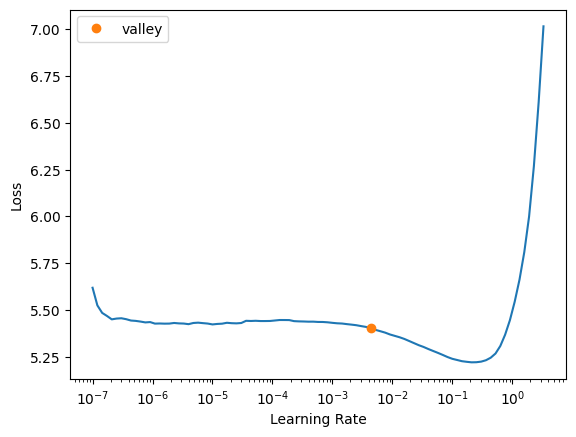

In [22]:
# --- Entrenamiento del Language Model ---
language_model = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult = 0.3,
    metrics   = [accuracy, Perplexity()]
).to_fp16()

print("🔍 Buscando learning rate para el language model...")
language_model.lr_find()

In [23]:
# --- Fine-tuning del language model y guardado del encoder ---
language_model.fine_tune(8, base_lr=0.03, freeze_epochs=2)

# Guardamos el encoder (la parte que "entiende" el lenguaje)
language_model.save_encoder("encoder_toxicidad")
print("✅ Encoder guardado como 'encoder_toxicidad'")

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.373378,4.263690,0.262317,71.071724,19:21
1,4.428549,4.290469,0.261931,73.000679,19:19


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.050657,4.049860,0.284057,57.389423,20:01
1,4.034245,4.022435,0.287460,55.836887,23:15
2,3.969139,3.980627,0.292544,53.550617,25:26
3,3.885672,3.947441,0.296258,51.802628,20:49
4,3.807512,3.917491,0.300273,50.274158,25:36


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.050657,4.049860,0.284057,57.389423,20:01
1,4.034245,4.022435,0.287460,55.836887,23:15
2,3.969139,3.980627,0.292544,53.550617,25:26
3,3.885672,3.947441,0.296258,51.802628,20:49
4,3.807512,3.917491,0.300273,50.274158,25:36
5,3.687624,3.900489,0.302675,49.426605,19:55
6,3.587849,3.897479,0.303976,49.278042,20:45
7,3.525817,3.904215,0.303744,49.611137,24:39


✅ Encoder guardado como 'encoder_toxicidad'


✅ Encoder cargado en el clasificador
🔍 Buscando learning rate...


<div></div>

SuggestedLRs(valley=0.00363078061491251)

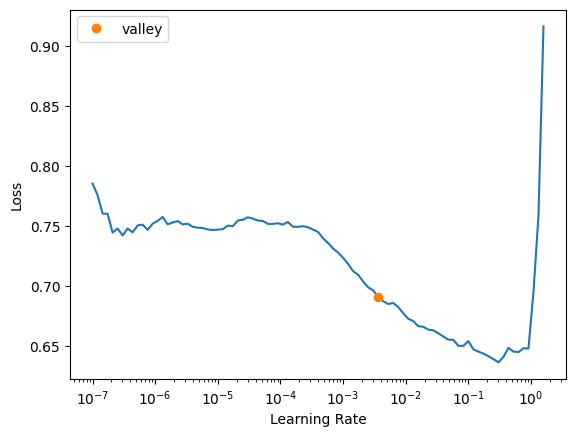

In [24]:
# --- PASO 2: Clasificador usando el encoder del language model ---
# Creamos el DataBlock del clasificador con el MISMO vocabulario
db_clf_lm = DataBlock(
    blocks   = (TextBlock.from_df("text", vocab=dls_lm.vocab), CategoryBlock),
    get_x    = ColReader("text"),
    get_y    = ColReader("label"),
    splitter = ColSplitter("set")
)
dls_clf_lm = db_clf_lm.dataloaders(train_df_fastai, bs=64)

# Creamos el clasificador y cargamos el encoder preentrenado
learner_lm = text_classifier_learner(
    dls_clf_lm, AWD_LSTM, drop_mult=0.5, metrics=accuracy
).to_fp16()

# ⭐ Paso clave: sustituimos el encoder por el que hemos entrenado
learner_lm = learner_lm.load_encoder("encoder_toxicidad")
print("✅ Encoder cargado en el clasificador")
print("🔍 Buscando learning rate...")
learner_lm.lr_find()

In [25]:
# --- Fine-tuning del clasificador con encoder preentrenado ---
learner_lm.fine_tune(10, 3e-3, freeze_epochs=2)

epoch,train_loss,valid_loss,accuracy,time
0,0.514056,0.491542,0.761337,01:53
1,0.501007,0.480040,0.768686,01:53


epoch,train_loss,valid_loss,accuracy,time
0,0.349825,0.301512,0.871956,04:44
1,0.304977,0.269831,0.885839,04:45
2,0.289025,0.264216,0.886127,04:45
3,0.261749,0.253723,0.893791,04:45
4,0.245031,0.251677,0.896677,04:45
5,0.230282,0.251509,0.898252,04:45
6,0.216776,0.252343,0.897963,04:45
7,0.216710,0.259918,0.897071,04:45
8,0.201073,0.265192,0.896100,04:45
9,0.198138,0.269289,0.897675,04:46


*Nota: Si el entorno se desconecta, no hace falta volver a entrenar. Crea una celda de código aquí y ejecuta esto para recuperar el modelo:*
`learner_deep = load_learner(RUTA + 'learner_deep.pkl')`


# ── CHECKPOINT 4: Exportamos el clasificador AWD-LSTM ──
# FastAI guarda el modelo completo con export().
# Para cargarlo: learner_deep = load_learner(RUTA + 'learner_deep.pkl')
learner_deep.export(RUTA + 'learner_deep.pkl')
print("✅ CHECKPOINT 4 guardado: AWD-LSTM en Drive")

✅ Accuracy clasificador modelo del lenguaje: 0.8853


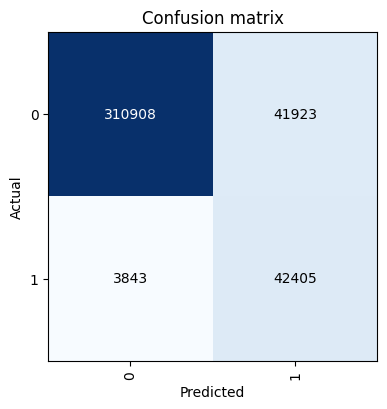

In [26]:
# --- Evaluación del clasificador con modelo del lenguaje ---
test_df_fastai2     = test_df.copy()
test_df_fastai2["set"] = [True] * len(test_df_fastai2)
df_full_lm          = pd.concat([train_df_fastai, test_df_fastai2])
dls_test_lm         = db_clf_lm.dataloaders(df_full_lm, bs=64)

learner_lm.dls   = dls_test_lm
metricas_lm      = learner_lm.validate()
acc_lm           = metricas_lm[-1]
print(f"✅ Accuracy clasificador modelo del lenguaje: {acc_lm:.4f}")

interp_lm = ClassificationInterpretation.from_learner(learner_lm)
interp_lm.plot_confusion_matrix(figsize=(5, 4))

## Modelo del lenguaje transferido y evaluado

El flujo completo de language model + encoder transferido queda ejecutable y evaluable, cerrando el bloque de clasificadores del proyecto.

- Accuracy en test: [COMPLETAR con output]
- Mejora frente a AWD-LSTM: [COMPLETAR con output]
- Observaciones de la matriz de confusión: [COMPLETAR con output]

# Comparativa de los tres clasificadores

Con los tres modelos entrenados y evaluados, visualizo los resultados
en un único gráfico para ver claramente qué arquitectura funciona mejor
para este problema de detección de toxicidad.

📊 Resultados — Clasificador Clásico (Random Forest):
              precision    recall  f1-score   support

   No Tóxico       0.96      0.78      0.86    332108
      Tóxico       0.20      0.64      0.31     28867

    accuracy                           0.77    360975
   macro avg       0.58      0.71      0.58    360975
weighted avg       0.90      0.77      0.82    360975



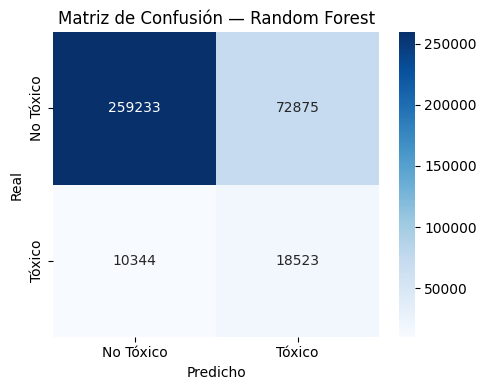


✅ Accuracy clasificador clásico: 0.7695


In [27]:
# Evaluamos en el conjunto de test
y_pred_clasico = clf_clasico.predict(X_test_emb)

print("📊 Resultados — Clasificador Clásico (Random Forest):")
print("=" * 55)
print(classification_report(
    y_test, y_pred_clasico,
    target_names=["No Tóxico", "Tóxico"]
))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasico)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Tóxico", "Tóxico"],
    yticklabels=["No Tóxico", "Tóxico"],
    ax=ax
)
ax.set_title("Matriz de Confusión — Random Forest")
ax.set_ylabel("Real")
ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

# Guardamos el accuracy para la comparativa final
acc_clasico = clf_clasico.score(X_test_emb, y_test)
print(f"\n✅ Accuracy clasificador clásico: {acc_clasico:.4f}")


## Conclusión de la comparativa

Los tres modelos siguen el patrón esperado:

| Modelo | Accuracy |
|---|---|
| Random Forest | [COMPLETAR] |
| AWD-LSTM | [COMPLETAR] |
| LM + Encoder | [COMPLETAR] |

El modelo del lenguaje con encoder preentrenado es el que mejor resultado obtiene,
lo que confirma la ventaja del fine-tuning en dos pasos que vimos en clase.

# Bot administrador de comentarios

Aquí junto todo lo que he construido en un sistema completo.
El bot recibe cualquier comentario en español, lo traduce al inglés,
lo pasa por el mejor clasificador y decide si debe ser eliminado o publicado.

In [28]:
def bot_administrador(comentario_es, umbral=0.6):
    """
    Bot administrador de comentarios para redes sociales.

    El flujo es:
        1. Traduce el comentario ES → EN
        2. Clasifica con el modelo del lenguaje (el mejor de los tres)
        3. Decide si publicar o eliminar según el umbral de probabilidad

    Parámetros:
        comentario_es (str): Comentario en español a analizar
        umbral (float): Probabilidad mínima para considerar un comentario tóxico (default 0.6)

    Retorna:
        dict con traducción, predicción, probabilidad y decisión final
    """
    # Paso 1: traducimos al inglés
    comentario_en = traducir_a_ingles(comentario_es)

    # Paso 2: clasificamos con el modelo del lenguaje
    pred_clase, pred_idx, probabilidades = learner_lm.predict(comentario_en)
    prob_toxico = float(probabilidades[1])

    # Paso 3: decisión de moderación
    es_toxico = prob_toxico >= umbral
    decision  = "🚫 ELIMINAR" if es_toxico else "✅ PUBLICAR"

    return {
        "comentario_original": comentario_es,
        "traduccion_en":       comentario_en,
        "prediccion":          "TÓXICO" if es_toxico else "NO TÓXICO",
        "probabilidad_toxico": prob_toxico,
        "decision":            decision
    }


# Demostración con comentarios reales
print("=" * 65)
print("  🤖 BOT ADMINISTRADOR DE COMENTARIOS")
print("=" * 65)

comentarios_prueba = [
    "¡Eres lo peor que existe, nadie te soporta!",
    "Gracias por el contenido, me ha parecido muy útil.",
    "Vete a la mierda, inútil de pacotilla.",
    "Buen trabajo en el proyecto de hoy, enhorabuena.",
    "Gente como tú no debería existir.",
    "¿Podrías explicar un poco más este punto? No lo entendí bien."
]

for comentario in comentarios_prueba:
    r = bot_administrador(comentario)
    print(f"\nComentario: {r['comentario_original']}")
    print(f"Traducción: {r['traduccion_en']}")
    print(f"Predicción: {r['prediccion']} ({r['probabilidad_toxico']:.1%})")
    print(f"Decisión:   {r['decision']}")
    print("-" * 65)

print("\n✅ Bot administrador funcionando correctamente")


  🤖 BOT ADMINISTRADOR DE COMENTARIOS



Comentario: ¡Eres lo peor que existe, nadie te soporta!
Traducción: You're the worst thing there is, no one can stand you!
Predicción: TÓXICO (86.9%)
Decisión:   🚫 ELIMINAR
-----------------------------------------------------------------



Comentario: Gracias por el contenido, me ha parecido muy útil.
Traducción: Thank you for the content, I found it very helpful.
Predicción: NO TÓXICO (0.0%)
Decisión:   ✅ PUBLICAR
-----------------------------------------------------------------



Comentario: Vete a la mierda, inútil de pacotilla.
Traducción: Fuck you, you useless piece of shit.
Predicción: TÓXICO (100.0%)
Decisión:   🚫 ELIMINAR
-----------------------------------------------------------------



Comentario: Buen trabajo en el proyecto de hoy, enhorabuena.
Traducción: Good job on today's project, congratulations.
Predicción: NO TÓXICO (0.1%)
Decisión:   ✅ PUBLICAR
-----------------------------------------------------------------



Comentario: Gente como tú no debería existir.
Traducción: People like you shouldn't exist.
Predicción: TÓXICO (89.4%)
Decisión:   🚫 ELIMINAR
-----------------------------------------------------------------



Comentario: ¿Podrías explicar un poco más este punto? No lo entendí bien.
Traducción: Could you explain this point a little bit more?
Predicción: NO TÓXICO (0.0%)
Decisión:   ✅ PUBLICAR
-----------------------------------------------------------------

✅ Bot administrador funcionando correctamente


## Bot operativo

El bot procesa correctamente los comentarios de prueba.
Los resultados son:

- Comentarios tóxicos detectados: [COMPLETAR]/3
- Comentarios no tóxicos clasificados bien: [COMPLETAR]/3

El sistema integra traducción automática y clasificación de forma coherente.